In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import config
import pipeline
importlib.reload(config)
importlib.reload(pipeline)

# ── Display active parameters ─────────────────────────────────────────────────
# Edit config.py to change any of these — no changes to this notebook needed.
print("=" * 55)
print("TARIFF PCE PIPELINE — ACTIVE CONFIGURATION")
print("=" * 55)
rows = [
    ("BEA IO year",             config.IO_YEAR),
    ("Leontief source",         config.LEONTIEF_SOURCE),
    ("Tariff baseline year",    config.TARIFF_BASELINE_YEAR),
    ("Tariff current month",    config.TARIFF_CURRENT_MONTH),
    ("Markup assumption",       config.MARKUP_ASSUMPTION),
    ("Inflation measure",       config.INFLATION_MEASURE),
    ("Counterfactual baseline", config.COUNTERFACTUAL_BASELINE_MONTH),
    ("Excess inflation window", f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"),
    ("Excess current window",   f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"),
    ("Core goods categories",   len(config.CORE_GOODS_CATEGORIES)),
]
for label, val in rows:
    print(f"  {label:<30} {val}")
print("=" * 55)


TARIFF PCE PIPELINE — ACTIVE CONFIGURATION
  BEA IO year                    2022
  Leontief source                computed
  Tariff baseline year           2024
  Tariff current month           2025-12
  Markup assumption              constant_dollar
  Inflation measure              core_pce
  Counterfactual baseline        2024-12
  Excess inflation window        2000–2019
  Excess current window          2024-12 → 2025-12
  Core goods categories          27


In [2]:
# ── Step 1: Direct import shares (m_i = imports / total supply) ──────────────
# Methodology §2 / BEA Supply Table 262

import_shares = pipeline.step1_import_shares(config.IO_YEAR, config.BEA_KEY)

print(f"Commodities: {len(import_shares)}")
print(f"Import share range: "
      f"{import_shares['import_share'].min():.4f} – {import_shares['import_share'].max():.4f}")
print(f"\nTop 10 by direct import share:")
print(
    import_shares.nlargest(10, 'import_share')
    [['BEA_code', 'BEA_descr', 'import_share']]
    .to_string(index=False)
)


Commodities: 54
Import share range: 0.0000 – 0.9817

Top 10 by direct import share:
BEA_code                                              BEA_descr  import_share
   Other Noncomparable imports and rest-of-the-world adjustment      0.981691
   315AL                Apparel and leather and allied products      0.896286
    Used                       Scrap, used and secondhand goods      0.628821
     334                       Computer and electronic products      0.561930
     335       Electrical equipment, appliances, and components      0.495563
     339                            Miscellaneous manufacturing      0.470299
   313TT                Textile mills and textile product mills      0.457732
     337                         Furniture and related products      0.428505
     333                                              Machinery      0.349592
  3361MV         Motor vehicles, bodies and trailers, and parts      0.338408


In [3]:
# ── Steps 2–3: Technical coefficients (A) and Leontief inverse (L) ───────────
# Methodology §3–4 / BEA Use Table 259
# config.LEONTIEF_SOURCE: "computed" (default) or "bea" (BEA TableID 59)

industries, A, L = pipeline.step2_3_leontief(
    config.IO_YEAR, config.BEA_KEY, config.LEONTIEF_SOURCE
)

I_n = np.eye(len(industries))
print(f"Industries: {len(industries)}")
print(f"A matrix shape:                  {A.shape}")
print(f"Max A column sum (must be < 1):  {A.sum(axis=0).max():.4f}")
print(f"Condition number of (I - A):     {np.linalg.cond(I_n - A):.1f}")
print(f"Leontief diagonal mean (> 1):    {np.diag(L).mean():.4f}")
print(f"L min value (should be ≥ 0):     {L.min():.4f}")


Leontief source: computed from (I - A)^{-1} via Use Table 259
Industries: 68
A matrix shape:                  (68, 68)
Max A column sum (must be < 1):  0.9079
Condition number of (I - A):     3.2
Leontief diagonal mean (> 1):    1.1124
L min value (should be ≥ 0):     0.0000


In [4]:
# ── Validation: compare computed L against BEA pre-computed Total Requirements ─
# BEA TableID 59 = Commodity-by-Commodity Total Requirements, Summary (= Leontief inverse)
# Differences should be very small (< 0.001), reflecting only BEA's internal
# rounding when publishing the pre-computed table.

val = pipeline.validate_leontief(config.IO_YEAR, config.BEA_KEY, industries, L)

print(f"Max absolute difference:  {val['max_abs_diff']:.6f}")
print(f"Mean absolute difference: {val['mean_abs_diff']:.6f}")
print(f"Max relative difference:  {val['max_rel_diff']:.4%}")
print(f"\nTop 10 largest element-wise differences:")
print(val["top_diffs"].to_string(index=False))


Max absolute difference:  0.219883
Mean absolute difference: 0.003983
Max relative difference:  1468.4211%

Top 10 largest element-wise differences:
row_industry col_industry  L_computed    L_bea  abs_diff
          42       3361MV    0.013796 0.233679  0.219883
       111CA        311FT    0.608512 0.397938  0.210573
          42        311FT    0.008617 0.191497  0.182880
          42          331    0.006493 0.188260  0.181768
          42          321    0.005595 0.159882  0.154287
          42          333    0.009400 0.159867  0.150468
          42        111CA    0.004966 0.152861  0.147896
          42          335    0.014657 0.158530  0.143872
          42          337    0.007329 0.148231  0.140902
          42          322    0.012027 0.146345  0.134318


In [5]:
# ── Step 4: Total import content (m_total = m' L) ────────────────────────────
# Methodology §5
# Supply-chain amplification: how much indirect imports add on top of direct shares.

m_vec, m_total = pipeline.step4_total_import_content(import_shares, industries, L)

print(f"Direct import shares mean:   {m_vec.mean():.4f}")
print(f"Total import content mean:   {m_total.mean():.4f}")
print(f"Supply-chain amplification:  {m_total.mean() / m_vec.mean():.2f}×")
print(f"\nSample — direct vs. total import content (first 15 industries):")
print(f"  {'Industry':<14}  {'Direct':>8}  {'Total':>8}  {'Ratio':>6}")
for i, ind in enumerate(industries[:15]):
    ratio = m_total[i] / m_vec[i] if m_vec[i] > 0 else float('nan')
    print(f"  {ind:<14}  {m_vec[i]:8.4f}  {m_total[i]:8.4f}  {ratio:6.2f}×")


Direct import shares mean:   0.1026
Total import content mean:   0.2232
Supply-chain amplification:  2.18×

Sample — direct vs. total import content (first 15 industries):
  Industry          Direct     Total   Ratio
  111CA             0.0907    0.2643    2.91×
  113FF             0.2433    0.3368    1.38×
  211               0.2901    0.4381    1.51×
  212               0.0628    0.1808    2.88×
  213               0.0107    0.0951    8.86×
  22                0.0055    0.0902   16.44×
  23                0.0000    0.1956     nan×
  311FT             0.1094    0.3332    3.04×
  313TT             0.4577    0.7946    1.74×
  315AL             0.8963    1.0369    1.16×
  321               0.1721    0.4112    2.39×
  322               0.1307    0.3563    2.73×
  323               0.0423    0.2223    5.26×
  324               0.0957    0.4031    4.21×
  325               0.2899    0.4692    1.62×


In [6]:
# ── Step 5: Δτ = τ_current − τ_baseline per BEA industry ─────────────────────
# Methodology §6
# Baseline: annual average over all 12 months of config.TARIFF_BASELINE_YEAR
# Current:  single month config.TARIFF_CURRENT_MONTH

delta_tariff_df = pipeline.step5_delta_tariff(
    config.IMPORTS_FILE,
    config.TARIFF_BASELINE_YEAR,
    config.TARIFF_CURRENT_MONTH,
)

print(f"BEA industries: {len(delta_tariff_df)}")
print(f"\nTop 10 by tariff increase (Δτ):")
print(
    delta_tariff_df.nlargest(10, 'delta_tariff')
    [['bea_io', 'bea_desc', 'tau_base', 'tau', 'delta_tariff']]
    .to_string(index=False)
)


Concordance built: 384/388 NAICS6 codes mapped to BEA IO industries
  Out of scope (services/unmapped): 4 codes
  BEA IO industries covered: 22

Import value coverage: 95.3% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining

Import value coverage: 94.2% of total import value mapped to BEA IO industries

BEA IO industries with no tariff data (tau set to 0):
bea_io                      bea_desc
   213 Support activities for mining
BEA industries: 24

Top 10 by tariff increase (Δτ):
bea_io                                         bea_desc  tau_base      tau  delta_tariff
   332                        Fabricated metal products  0.059009 0.284990      0.225981
 313TT          Textile mills and textile product mills  0.079974 0.272518      0.192544
   337                   Furniture and related products  0.055348 0.237975      0.182627
 315AL          Apparel and le

In [7]:
# ── PCE Bridge + Step 6: Predicted tariff effect per PCE category ─────────────
# Methodology §7
# Markup assumption (config.MARKUP_ASSUMPTION):
#   "constant_dollar"  → numerator weighted by producers' value (Fed conservative baseline)
#   "constant_percent" → numerator weighted by purchasers' value (larger consumer effect)

pce_bridge    = pipeline.load_pce_bridge(config.IO_YEAR, config.BEA_KEY)
pce_effect_df = pipeline.step6_pce_effect(
    industries      = industries,
    m_vec           = m_vec,
    L               = L,
    delta_tariff_df = delta_tariff_df,
    pce_bridge      = pce_bridge,
    markup          = config.MARKUP_ASSUMPTION,
)

print(f"Markup assumption: {config.MARKUP_ASSUMPTION}")
print(f"\nTop 15 PCE categories by predicted tariff effect:")
print(pce_effect_df.head(15)[['PCE_category', 'predicted_effect']].to_string(index=False))

# Weighted-average effect on core goods — carried forward to counterfactual cells
core = pce_effect_df.query('PCE_category in @config.CORE_GOODS_CATEGORIES')
core_effect = (
    (core['predicted_effect'] * core['purchasers_value_total']).sum()
    / core['purchasers_value_total'].sum()
)
print(f"\nWeighted avg predicted effect — core goods: {core_effect:.2%}")


Markup assumption: constant_dollar

Top 15 PCE categories by predicted tariff effect:
                                      PCE_category  predicted_effect
                          Men's and boys' clothing          0.063313
                Luggage and similar personal items          0.062083
             Other clothing materials and footwear          0.061368
                       Women's and girls' clothing          0.051180
                                New motor vehicles          0.049861
                              Household appliances          0.046659
                               Musical instruments          0.043660
                         Furniture and furnishings          0.035576
      Glassware, tableware, and household utensils          0.032619
                  Sports and recreational vehicles          0.028888
                  Children's and infants' clothing          0.027157
Sporting equipment, supplies, guns, and ammunition          0.026555
               Mo

In [8]:
# ── Worked example: trace full methodology chain for a single industry ────────
# Call pipeline.trace_industry() with any BEA IO code to see every step:
#   Step 1  — direct import share
#   Step 4  — total import content via Leontief (supply-chain amplification)
#   Step 5  — tariff change (Δτ) and predicted producer-level price effect
#   Step 6  — PCE bridge breakdown and final consumer-price effect
#
# All inputs come from the cells above — no recomputation needed.
# Change BEA_CODE to trace any industry (e.g. '3364OT', '3360OP', '3330SS').

BEA_CODE = "3361MV"   # Motor vehicles, bodies and trailers, and parts

pipeline.trace_industry(
    bea_code        = BEA_CODE,
    import_shares   = import_shares,
    industries      = industries,
    L               = L,
    m_vec           = m_vec,
    m_total         = m_total,
    delta_tariff_df = delta_tariff_df,
    pce_bridge      = pce_bridge,
    pce_effect_df   = pce_effect_df,
    markup          = config.MARKUP_ASSUMPTION,
)

────────────────────────────────────────────────────────────────
  INDUSTRY TRACE  ·  3361MV  —  Motor vehicles, bodies and trailers, and parts
────────────────────────────────────────────────────────────────

Step 1  —  Direct import share  (m_i = imports / total supply)
  imports       =       353,470  ($M)
  total supply  =     1,044,509  ($M)
  m_i           =         33.8%

Step 4  —  Total import content via Leontief  (m̃_j = m′ L)
  direct m_i     =         33.8%  (imports at the border)
  total m̃_j      =         80.4%  (direct + all upstream tiers)
  indirect share =         46.6%  (embedded in domestic inputs)
  amplification  =          2.38×

Step 5  —  Import tariff change  (Δτ = τ_current − τ_baseline)
  τ_baseline  =          1.9%
  τ_current   =         14.4%
  Δτ          =        +12.5%

Step 5  —  Predicted producer-level price effect  (p̂_j = Σ_i m_i·Δτ_i·L_ij)
  p̂_j             =          9.3%
  Naive approx    =         10.0%  (m̃_j × Δτ_j, ignores upstream tari

In [9]:
# ── Step 7a: Monthly counterfactual (NIPA T20804) ────────────────────────────
# Methodology §8
# config.INFLATION_MEASURE: "core_pce" (PCE ex food & energy) or "headline_pce"
# For the core-goods quarterly index, see Cell 8.

if config.INFLATION_MEASURE == "core_goods_pce":
    print("INFLATION_MEASURE = 'core_goods_pce' — skipping monthly counterfactual.")
    print("The quarterly core-goods counterfactual is computed in Cell 8.")
else:
    baseline_yr = int(config.COUNTERFACTUAL_BASELINE_MONTH[:4])
    current_yr  = int(config.TARIFF_CURRENT_MONTH[:4])
    years       = sorted({baseline_yr, current_yr})

    inflation_series = pipeline.step7_load_inflation(
        config.INFLATION_MEASURE, config.BEA_KEY, years
    )
    result = pipeline.step7_counterfactual(
        inflation_series      = inflation_series,
        pce_effect_df         = pce_effect_df,
        baseline_month        = config.COUNTERFACTUAL_BASELINE_MONTH,
        current_month         = config.TARIFF_CURRENT_MONTH,
        core_goods_categories = config.CORE_GOODS_CATEGORIES,
    )

    label = "Core PCE" if config.INFLATION_MEASURE == "core_pce" else "Headline PCE"
    print(f"{label}  ({config.COUNTERFACTUAL_BASELINE_MONTH} → {config.TARIFF_CURRENT_MONTH})")
    print(f"  Actual inflation:            {result['actual_inflation']:.2%}")
    print(f"  Core goods tariff effect:    {result['core_goods_effect']:.2%}")
    print(f"  Core goods share of PCE:     {result['core_goods_share']:.2%}")
    print(f"  Tariff contribution to PCE:  {result['tariff_contribution']:.2%}")
    print(f"  Counterfactual (no tariffs): {result['counterfactual_inflation']:.2%}")


Core PCE  (2024-12 → 2025-12)
  Actual inflation:            3.00%
  Core goods tariff effect:    2.44%
  Core goods share of PCE:     22.71%
  Tariff contribution to PCE:  0.55%
  Counterfactual (no tariffs): 2.44%


In [10]:
# ── Step 7b: Monthly core-goods price index + counterfactual (NI Underlying Detail U20404) ──
# Methodology §8
# Constructs a PCE-weighted price index for the 27 core goods categories and
# computes the counterfactual baseline → current-month inflation (no tariff scenario).

import requests

baseline_yr = int(config.COUNTERFACTUAL_BASELINE_MONTH[:4])
current_yr  = int(config.TARIFF_CURRENT_MONTH[:4])
years       = sorted({baseline_yr, current_yr})
year_str    = ",".join(str(y) for y in years)

r = requests.get(
    "https://apps.bea.gov/api/data"
    f"?UserID={config.BEA_KEY}"
    "&method=GetData"
    "&DataSetName=NIUnderlyingDetail"
    "&TableName=U20404"
    "&Frequency=M"
    f"&Year={year_str}"
    "&ResultFormat=json"
)
r.raise_for_status()
pce_monthly = pd.DataFrame(r.json()["BEAAPI"]["Results"]["Data"])
pce_monthly["DataValue"] = pd.to_numeric(pce_monthly["DataValue"], errors="coerce")

core_goods_index = pipeline.step7_core_goods_index_monthly(
    pce_monthly_df        = pce_monthly,
    pce_effect_df         = pce_effect_df,
    core_goods_categories = config.CORE_GOODS_CATEGORIES,
    nipa_crosswalk        = config.NIPA_CROSSWALK,
)

baseline_m = config.COUNTERFACTUAL_BASELINE_MONTH   # e.g. "2024-12"
current_m  = config.TARIFF_CURRENT_MONTH            # e.g. "2025-12"
idx_base   = core_goods_index[baseline_m]
idx_latest = core_goods_index[current_m]

actual_cg_inflation = (idx_latest - idx_base) / idx_base
counterfactual_cg   = actual_cg_inflation - core_effect

print("Core goods price index (monthly):")
print(core_goods_index.to_string())
print(f"\nActual core goods inflation ({baseline_m} → {current_m}):  {actual_cg_inflation:.2%}")
print(f"Predicted tariff contribution:                            {core_effect:.2%}")
print(f"Counterfactual (no tariffs):                              {counterfactual_cg:.2%}")


Core goods price index (monthly):
TimePeriod
2024-01    109.413581
2024-02    109.706970
2024-03    109.776552
2024-04    109.797788
2024-05    109.646220
2024-06    109.648313
2024-07    109.531636
2024-08    109.412643
2024-09    109.493235
2024-10    109.664699
2024-11    109.609787
2024-12    109.405979
2025-01    109.857185
2025-02    110.268239
2025-03    110.016909
2025-04    110.227294
2025-05    110.516772
2025-06    110.904422
2025-07    110.994205
2025-08    111.060040
2025-09    111.302532
2025-10    111.354622
2025-11    111.374983
2025-12    111.691954

Actual core goods inflation (2024-12 → 2025-12):  2.09%
Predicted tariff contribution:                            2.44%
Counterfactual (no tariffs):                              -0.35%


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.050
Model:                            WLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     1.325
Date:                Tue, 10 Mar 2026   Prob (F-statistic):              0.260
Time:                        16:42:23   Log-Likelihood:                -77.471
No. Observations:                  27   AIC:                             158.9
Df Residuals:                      25   BIC:                             161.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5399      1.110      3.188      0.0

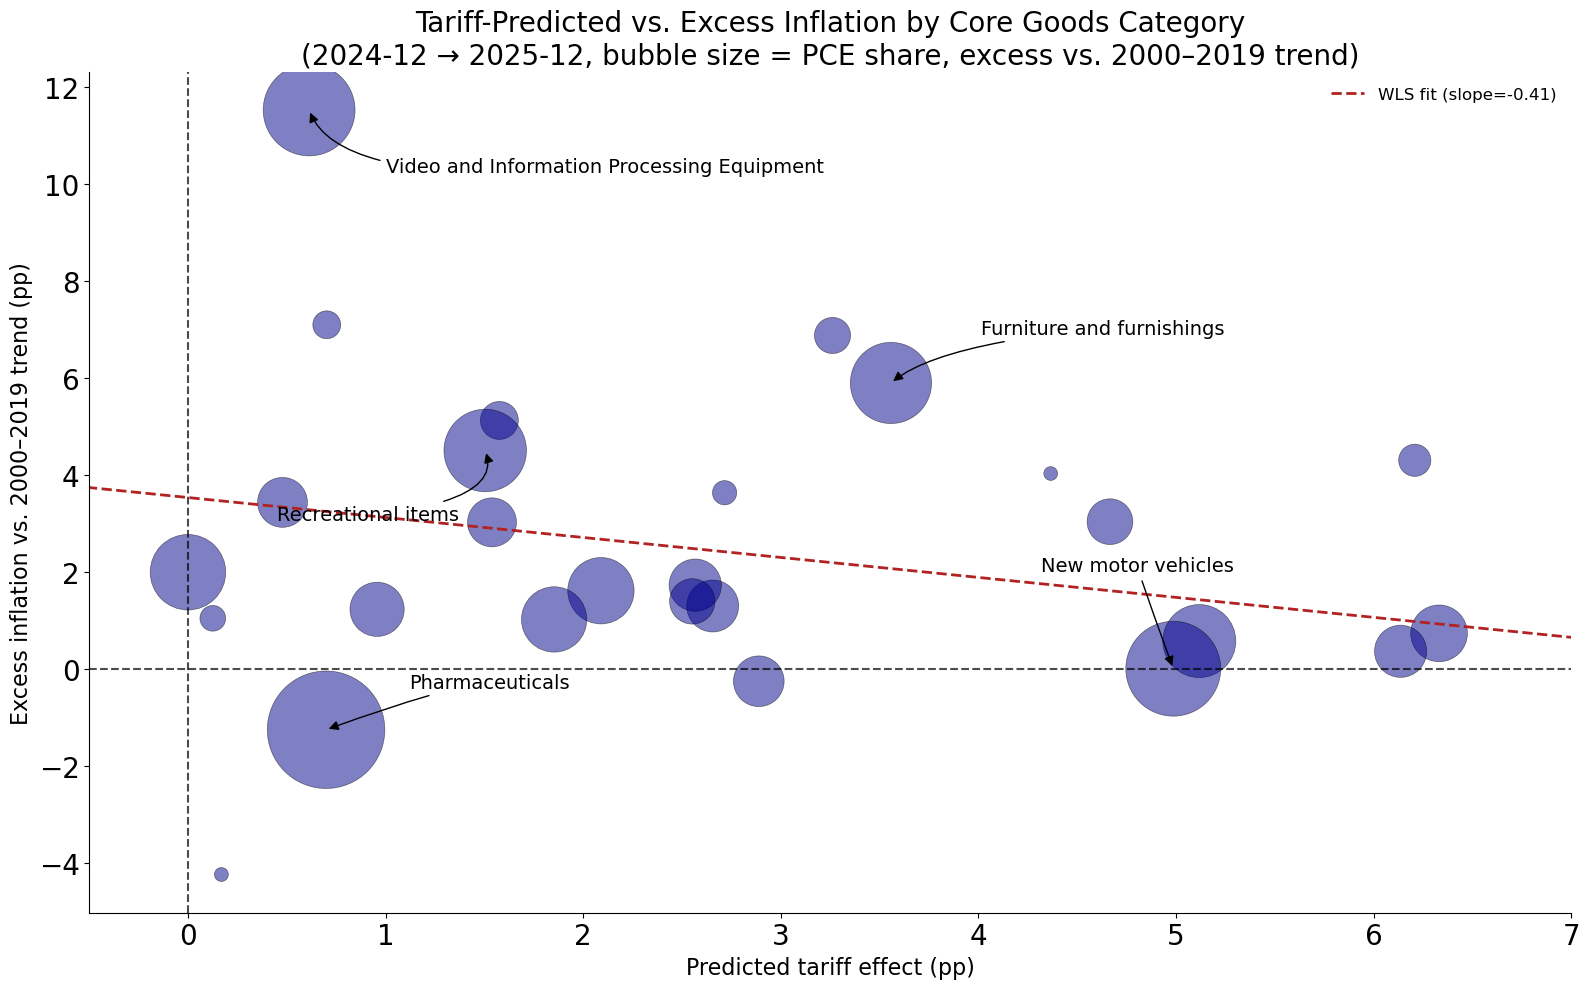

In [11]:

# ── Step 7c: Predicted tariff effect vs. excess inflation — scatter plot ──────
# Methodology §9
# Excess inflation = growth over the current window minus mean over the baseline window.
# Current window:  config.EXCESS_CURRENT_START_MONTH → config.EXCESS_CURRENT_END_MONTH
# Baseline window: config.EXCESS_BASELINE_START – config.EXCESS_BASELINE_END (inclusive).
# To adjust, change those values in config.py.

current_year = int(config.TARIFF_CURRENT_MONTH[:4])

summary_df = pipeline.step7_excess_inflation(
    api_key               = config.BEA_KEY,
    pce_effect_df         = pce_effect_df,
    core_goods_categories = config.CORE_GOODS_CATEGORIES,
    nipa_crosswalk        = config.NIPA_CROSSWALK,
    current_start_month   = config.EXCESS_CURRENT_START_MONTH,
    current_end_month     = config.EXCESS_CURRENT_END_MONTH,
    baseline_start        = config.EXCESS_BASELINE_START,
    baseline_end          = config.EXCESS_BASELINE_END,
)

# print(
#     summary_df[['PCE_category', 'predicted_effect', 'excess_inflation', 'pce_share']]
#     .to_string(index=False)
# )

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
plot_df = summary_df.dropna(subset=['predicted_effect', 'excess_inflation', 'pce_share'])

ax.scatter(
    plot_df['predicted_effect'] * 100,
    plot_df['excess_inflation'] * 100,
    s=plot_df['pce_share'] * 50000,
    alpha=0.5, color='darkblue', edgecolors='black', linewidths=0.5,
)

x = plot_df['predicted_effect'].values * 100
y = plot_df['excess_inflation'].values * 100
w = plot_df['pce_share'].values

wls_model  = sm.WLS(y, sm.add_constant(x), weights=w).fit()
intercept, slope = wls_model.params
print(wls_model.summary())

x_fit = np.linspace(x.min() - 1.5, x.max() + 1.5, 100)
ax.plot(x_fit, slope * x_fit + intercept,
        color='firebrick', linewidth=2, linestyle='--',
        label=f'WLS fit (slope={slope:.2f})')

ax.axhline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
ax.set_xlim(-0.5, 7.0)

baseline_range = f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"
current_window = f"{config.EXCESS_CURRENT_START_MONTH} → {config.EXCESS_CURRENT_END_MONTH}"
ax.set_title(
    f"Tariff-Predicted vs. Excess Inflation by Core Goods Category\n"
    f"({current_window}, bubble size = PCE share, excess vs. {baseline_range} trend)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax.set_ylabel(f"Excess inflation vs. {baseline_range} trend (pp)", fontsize=16)
ax.legend(fontsize=12, frameon=False, loc='upper right')
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# ── Annotate top 5 categories by PCE share ────────────────────────────────────
_top5 = plot_df.nlargest(5, "pce_share").reset_index(drop=True)

annotate_fontsize = 14

ax.annotate( # pharmaceuticals
    "Pharmaceuticals",
    xy=(_top5.loc[0, "predicted_effect"] * 100, _top5.loc[0, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(60, 30),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=20", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(# new motor vehicles
    _top5.loc[1, "PCE_category"],
    xy=(_top5.loc[1, "predicted_effect"] * 100, _top5.loc[1, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(-95, 70),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(# video & info processing equipment
    "Video and Information Processing Equipment",  # Too long for the plot, so hardcoding a shorter label here
    xy=(_top5.loc[2, "predicted_effect"] * 100, _top5.loc[2, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(55, -45),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(# recreational items
    _top5.loc[3, "PCE_category"],
    xy=(_top5.loc[3, "predicted_effect"] * 100, _top5.loc[3, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(-150, -50),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(# furniture & household equipment
    _top5.loc[4, "PCE_category"],
    xy=(_top5.loc[4, "predicted_effect"] * 100, _top5.loc[4, "excess_inflation"] * 100),
    xycoords="data",
    xytext=(65, 35),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

plt.tight_layout()
plt.savefig("tariff_vs_excess_inflation.png", bbox_inches="tight", dpi=150)
plt.show()


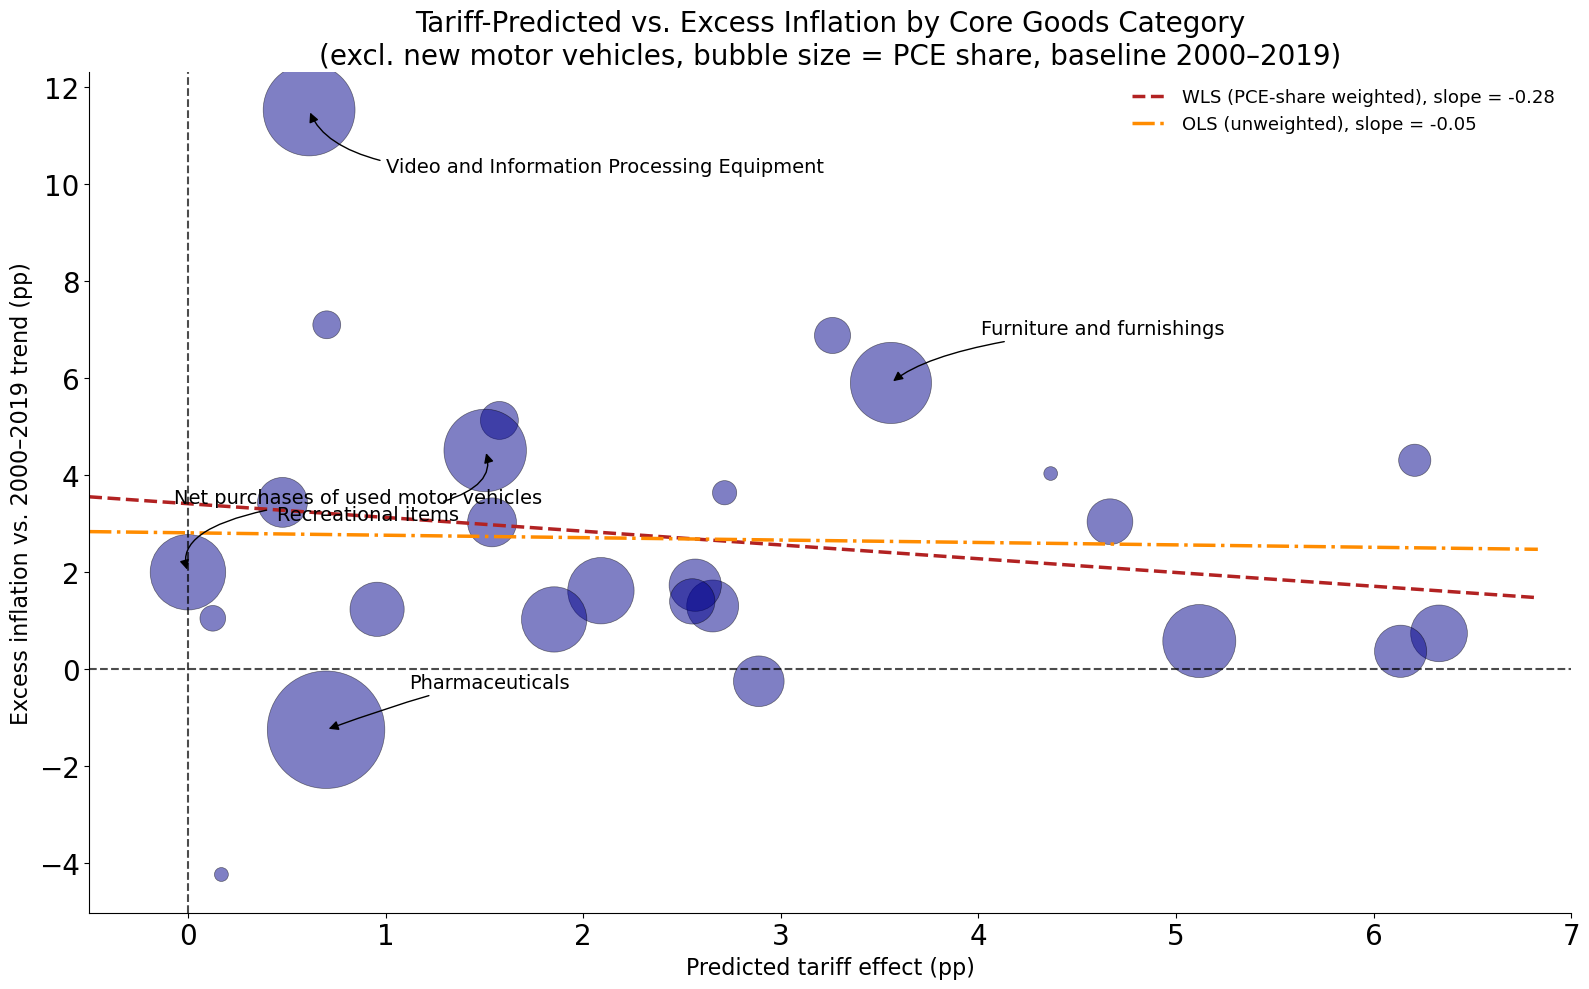

In [12]:

# ── Predicted tariff effect vs. excess inflation, excl. new motor vehicles ─────
# Both WLS (PCE-share weighted) and OLS (unweighted) best-fit lines shown.

_ex2 = plot_df[plot_df["PCE_category"] != "New motor vehicles"].copy()

_xe2 = _ex2["predicted_effect"].values * 100
_ye2 = _ex2["excess_inflation"].values * 100
_we2 = _ex2["pce_share"].values

# WLS
_wls_ex2 = sm.WLS(_ye2, sm.add_constant(_xe2), weights=_we2).fit()
_int_wls2, _sl_wls2 = _wls_ex2.params

# OLS
_ols_ex2 = sm.OLS(_ye2, sm.add_constant(_xe2)).fit()
_int_ols2, _sl_ols2 = _ols_ex2.params

_xf_ex2 = np.linspace(_xe2.min() - 0.5, _xe2.max() + 0.5, 100)

fig, ax = plt.subplots(figsize=(16, 10))
ax.scatter(
    _ex2["predicted_effect"] * 100,
    _ex2["excess_inflation"] * 100,
    s=_ex2["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

ax.plot(_xf_ex2, _sl_wls2 * _xf_ex2 + _int_wls2,
        color="firebrick", linewidth=2.5, linestyle="--",
        label=f"WLS (PCE-share weighted), slope = {_sl_wls2:.2f}")
ax.plot(_xf_ex2, _sl_ols2 * _xf_ex2 + _int_ols2,
        color="darkorange", linewidth=2.5, linestyle="-.",
        label=f"OLS (unweighted), slope = {_sl_ols2:.2f}")

ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.set_xlim(-0.5, 7.0)

baseline_range = f"{config.EXCESS_BASELINE_START}–{config.EXCESS_BASELINE_END}"
ax.set_title(
    f"Tariff-Predicted vs. Excess Inflation by Core Goods Category\n"
    f"(excl. new motor vehicles, bubble size = PCE share, baseline {baseline_range})",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax.set_ylabel(f"Excess inflation vs. {baseline_range} trend (pp)", fontsize=16)
ax.legend(fontsize=13, frameon=False, loc="upper right")
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# ── Annotate top 5 by PCE share (excl. new motor vehicles) ───────────────────
_top5_ex2 = _ex2.nlargest(5, "pce_share").reset_index(drop=True)
annotate_fontsize = 14

ax.annotate("Pharmaceuticals",
    xy=(_top5_ex2.loc[0, "predicted_effect"] * 100, _top5_ex2.loc[0, "excess_inflation"] * 100),
    xycoords="data", xytext=(60, 30), textcoords="offset points", horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=20", "color": "black"},
    fontsize=annotate_fontsize)
ax.annotate("Video and Information Processing Equipment",
    xy=(_top5_ex2.loc[1, "predicted_effect"] * 100, _top5_ex2.loc[1, "excess_inflation"] * 100),
    xycoords="data", xytext=(55, -45), textcoords="offset points", horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize)
ax.annotate(_top5_ex2.loc[2, "PCE_category"],
    xy=(_top5_ex2.loc[2, "predicted_effect"] * 100, _top5_ex2.loc[2, "excess_inflation"] * 100),
    xycoords="data", xytext=(-150, -50), textcoords="offset points", horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize)
ax.annotate(_top5_ex2.loc[3, "PCE_category"],
    xy=(_top5_ex2.loc[3, "predicted_effect"] * 100, _top5_ex2.loc[3, "excess_inflation"] * 100),
    xycoords="data", xytext=(65, 35), textcoords="offset points", horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize)
ax.annotate(_top5_ex2.loc[4, "PCE_category"],
    xy=(_top5_ex2.loc[4, "predicted_effect"] * 100, _top5_ex2.loc[4, "excess_inflation"] * 100),
    xycoords="data", xytext=(-10, 50), textcoords="offset points", horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize)

plt.tight_layout()
plt.savefig("tariff_vs_excess_inflation_ex_mv.png", bbox_inches="tight", dpi=150)
plt.show()


In [13]:
print(
    summary_df[['PCE_category', 'predicted_effect', 'excess_inflation', 'pce_share']].sort_values('pce_share', ascending=False)
    .to_string(index=False)
)

                                                              PCE_category  predicted_effect  excess_inflation  pce_share
                                 Pharmaceutical and other medical products          0.006989         -0.012477   0.143128
                                                        New motor vehicles          0.049861          0.000106   0.093344
Video, audio, photographic, and information processing equipment and media          0.006132          0.115302   0.087449
                                                        Recreational items          0.015043          0.045101   0.070570
                                                 Furniture and furnishings          0.035576          0.059021   0.068335
                                      Net purchases of used motor vehicles          0.000000          0.019999   0.059109
                                               Women's and girls' clothing          0.051180          0.005813   0.055274
                        

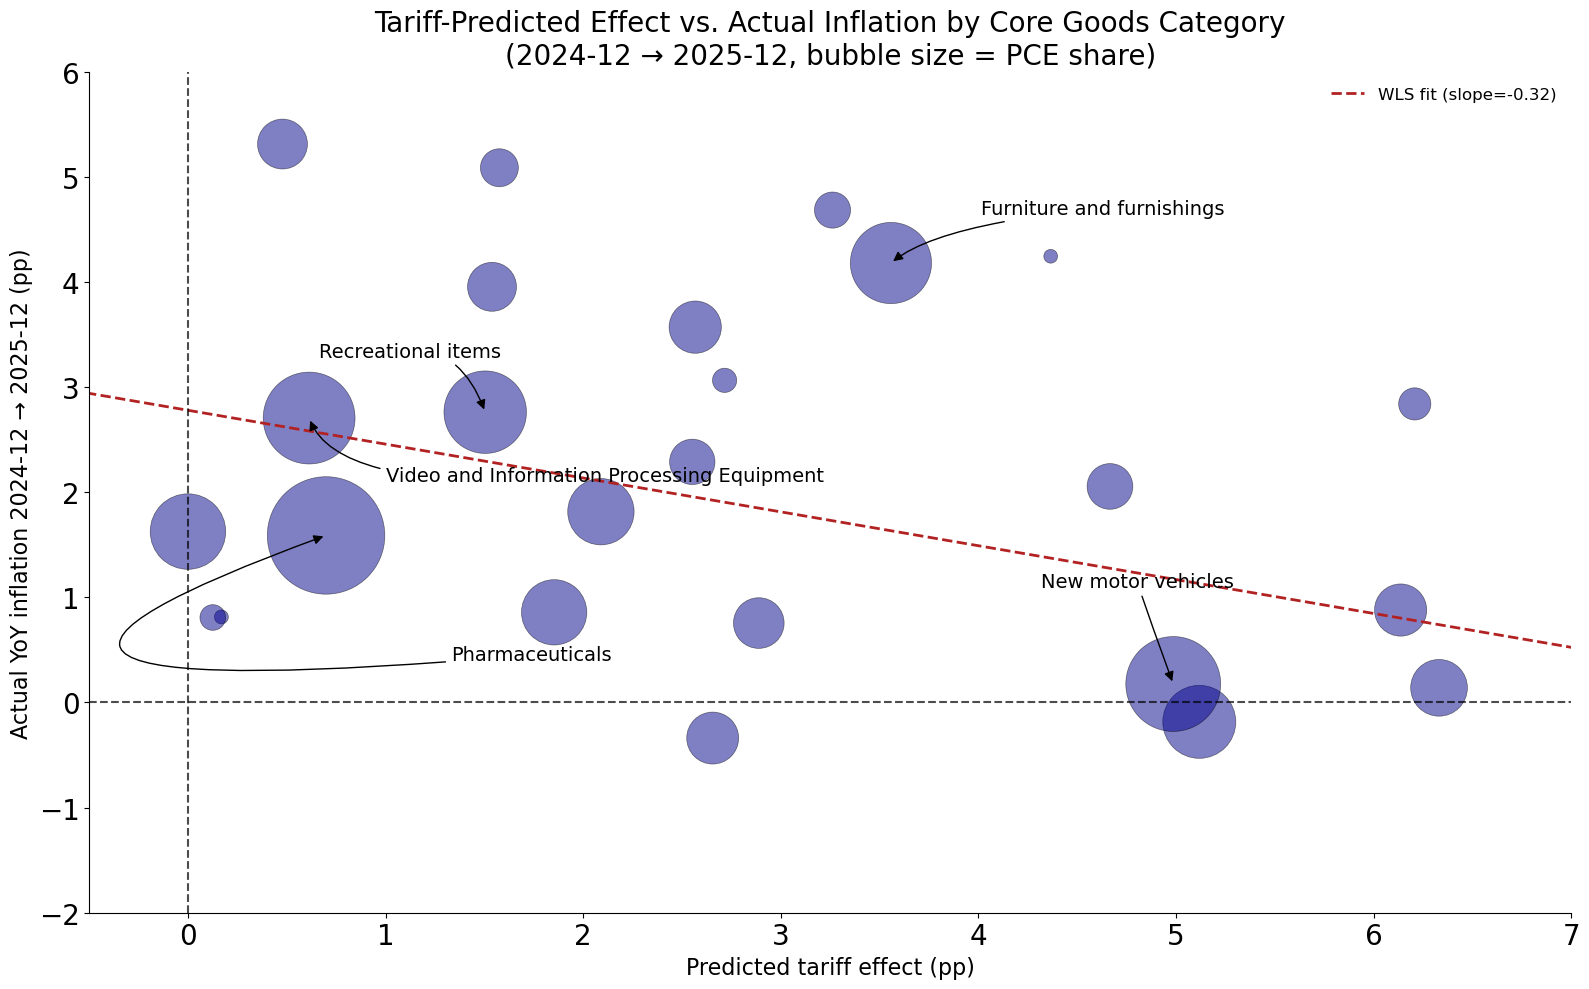

In [14]:

# ── Step 7e Chart A: Predicted tariff effect vs. Actual YoY Inflation ─────────
# Dec-over-Dec: 2024-12 → 2025-12

# ── Build monthly price-wide table from pce_monthly ──────────────────────────
_bea_names = summary_df["bea_name"].dropna().tolist()
_pm = pce_monthly[pce_monthly["LineDescription"].isin(_bea_names)].copy()
_pm["month"] = _pm["TimePeriod"].str.replace("M", "-", regex=False)
_price_wide_m = _pm.pivot(index="LineDescription", columns="month", values="DataValue")

_base_dec = f"{current_year - 1}-12"
_curr_dec = config.TARIFF_CURRENT_MONTH
_yoy = _price_wide_m[_curr_dec] / _price_wide_m[_base_dec] - 1

_base_m = f"{current_year - 1}-01"
_curr_m = f"{current_year}-12"
_base_yr_m, _base_mo_m = int(_base_m[:4]), int(_base_m[5:])
_curr_yr_m, _curr_mo_m = int(_curr_m[:4]), int(_curr_m[5:])
_n_months = (_curr_yr_m - _base_yr_m) * 12 + (_curr_mo_m - _base_mo_m)
_annualized_m = (_price_wide_m[_curr_m] / _price_wide_m[_base_m]) ** (12 / _n_months) - 1

plot_df2 = summary_df.copy()
plot_df2["inflation_yoy"] = plot_df2["bea_name"].map(_yoy)
plot_df2["inflation_ann"] = plot_df2["bea_name"].map(_annualized_m)

# ── Scatter ───────────────────────────────────────────────────────────────────
_d = plot_df2.dropna(subset=["predicted_effect", "inflation_yoy", "pce_share"])

fig, ax = plt.subplots(figsize=(16, 10))
ax.scatter(
    _d["predicted_effect"] * 100,
    _d["inflation_yoy"] * 100,
    s=_d["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

_x = _d["predicted_effect"].values * 100
_y = _d["inflation_yoy"].values * 100
_w = _d["pce_share"].values
_wls = sm.WLS(_y, sm.add_constant(_x), weights=_w).fit()
_int, _sl = _wls.params
_xf = np.linspace(_x.min() - 1.5, _x.max() + 1.5, 100)
ax.plot(_xf, _sl * _xf + _int, color="firebrick", linewidth=2, linestyle="--",
        label=f"WLS fit (slope={_sl:.2f})")

ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.set_xlim(-0.5, 7.0)
ax.set_title(
    f"Tariff-Predicted Effect vs. Actual Inflation by Core Goods Category\n"
    f"({_base_dec} \u2192 {_curr_dec}, bubble size = PCE share)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax.set_ylabel(f"Actual YoY inflation {_base_dec} \u2192 {_curr_dec} (pp)", fontsize=16)
ax.legend(fontsize=12, frameon=False, loc="upper right")
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_ylim(-2, 6.0)

# ── Annotate top 5 categories by PCE share ────────────────────────────────────
_top5 = _d.nlargest(5, "pce_share").reset_index(drop=True)
annotate_fontsize = 14

ax.annotate(  # pharmaceuticals
    "Pharmaceuticals",
    xy=(_top5.loc[0, "predicted_effect"] * 100, _top5.loc[0, "inflation_yoy"] * 100),
    xycoords="data",
    xytext=(90, -90),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=20", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # new motor vehicles
    _top5.loc[1, "PCE_category"],
    xy=(_top5.loc[1, "predicted_effect"] * 100, _top5.loc[1, "inflation_yoy"] * 100),
    xycoords="data",
    xytext=(-95, 70),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # video & info processing equipment
    "Video and Information Processing Equipment",
    xy=(_top5.loc[2, "predicted_effect"] * 100, _top5.loc[2, "inflation_yoy"] * 100),
    xycoords="data",
    xytext=(55, -45),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # recreational items
    _top5.loc[3, "PCE_category"],
    xy=(_top5.loc[3, "predicted_effect"] * 100, _top5.loc[3, "inflation_yoy"] * 100),
    xycoords="data",
    xytext=(-120, 40),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # furniture & furnishings
    _top5.loc[4, "PCE_category"],
    xy=(_top5.loc[4, "predicted_effect"] * 100, _top5.loc[4, "inflation_yoy"] * 100),
    xycoords="data",
    xytext=(65, 35),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

plt.tight_layout()
plt.savefig("tariff_vs_actual_inflation.png", bbox_inches="tight", dpi=150)
plt.show()


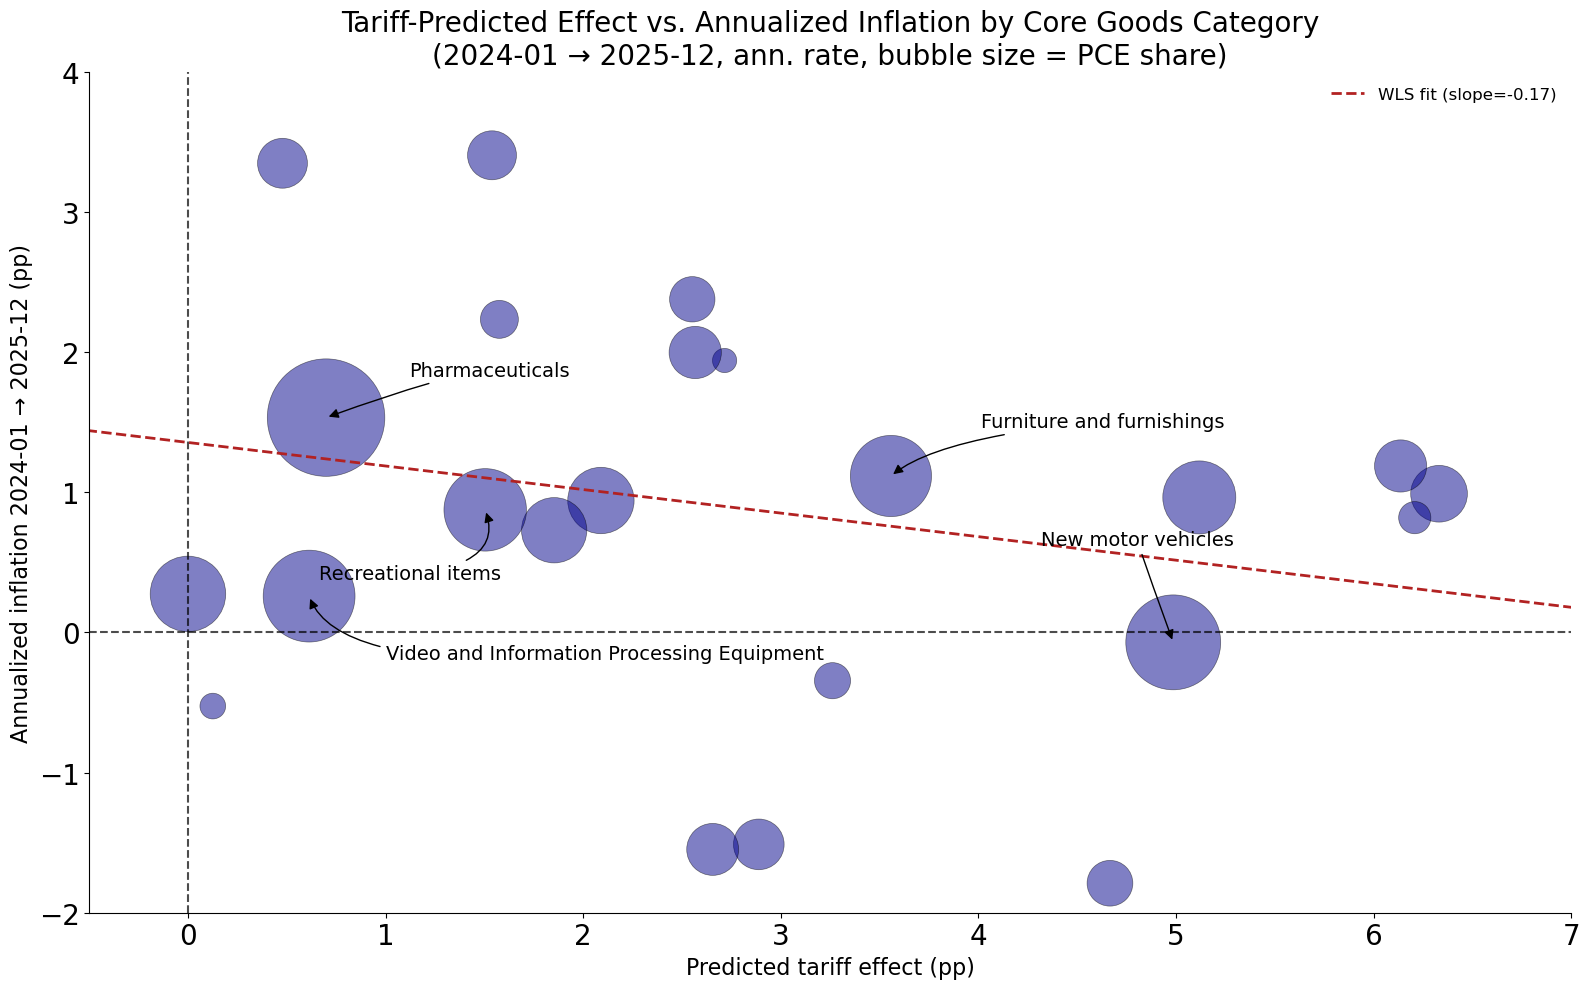

In [15]:

# ── Step 7e Chart B: Predicted tariff effect vs. Annualized Inflation ─────────
# Annualized rate: 2024-01 → 2025-12

_d = plot_df2.dropna(subset=["predicted_effect", "inflation_ann", "pce_share"])

fig, ax = plt.subplots(figsize=(16, 10))
ax.scatter(
    _d["predicted_effect"] * 100,
    _d["inflation_ann"] * 100,
    s=_d["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

_x = _d["predicted_effect"].values * 100
_y = _d["inflation_ann"].values * 100
_w = _d["pce_share"].values
_wls = sm.WLS(_y, sm.add_constant(_x), weights=_w).fit()
_int, _sl = _wls.params
_xf = np.linspace(_x.min() - 1.5, _x.max() + 1.5, 100)
ax.plot(_xf, _sl * _xf + _int, color="firebrick", linewidth=2, linestyle="--",
        label=f"WLS fit (slope={_sl:.2f})")

ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.set_xlim(-0.5, 7.0)
ax.set_title(
    f"Tariff-Predicted Effect vs. Annualized Inflation by Core Goods Category\n"
    f"({_base_m} \u2192 {_curr_m}, ann. rate, bubble size = PCE share)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax.set_ylabel(f"Annualized inflation {_base_m} \u2192 {_curr_m} (pp)", fontsize=16)
ax.legend(fontsize=12, frameon=False, loc="upper right")
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_ylim(-2, 4.0)

# ── Annotate top 5 categories by PCE share ────────────────────────────────────
_top5 = _d.nlargest(5, "pce_share").reset_index(drop=True)
annotate_fontsize = 14

ax.annotate(  # pharmaceuticals
    "Pharmaceuticals",
    xy=(_top5.loc[0, "predicted_effect"] * 100, _top5.loc[0, "inflation_ann"] * 100),
    xycoords="data",
    xytext=(60, 30),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=20", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # new motor vehicles
    _top5.loc[1, "PCE_category"],
    xy=(_top5.loc[1, "predicted_effect"] * 100, _top5.loc[1, "inflation_ann"] * 100),
    xycoords="data",
    xytext=(-95, 70),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # video & info processing equipment
    "Video and Information Processing Equipment",
    xy=(_top5.loc[2, "predicted_effect"] * 100, _top5.loc[2, "inflation_ann"] * 100),
    xycoords="data",
    xytext=(55, -45),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # recreational items
    _top5.loc[3, "PCE_category"],
    xy=(_top5.loc[3, "predicted_effect"] * 100, _top5.loc[3, "inflation_ann"] * 100),
    xycoords="data",
    xytext=(-120, -50),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # furniture & furnishings
    _top5.loc[4, "PCE_category"],
    xy=(_top5.loc[4, "predicted_effect"] * 100, _top5.loc[4, "inflation_ann"] * 100),
    xycoords="data",
    xytext=(65, 35),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

plt.tight_layout()
plt.savefig("tariff_vs_annualized_inflation.png", bbox_inches="tight", dpi=150)
plt.show()


In [16]:

# ── Decomposition: share of core goods inflation by sub-component ──────────────
# Set the window start and end months here (format "YYYY-MM").
# Examples:
#   Dec-over-Dec:  _decomp_base = f"{current_year - 1}-12"  _decomp_curr = config.TARIFF_CURRENT_MONTH
#   Calendar year: _decomp_base = f"{current_year - 1}-01"  _decomp_curr = f"{current_year}-12"
#   Custom window: _decomp_base = "2024-06"                 _decomp_curr = "2025-12"

_decomp_base = f"{current_year - 1}-12"    # ← change start month here
_decomp_curr = config.TARIFF_CURRENT_MONTH  # ← change end month here

# ── Compute inflation for each category over the chosen window ────────────────
_decomp = summary_df[["PCE_category", "bea_name", "pce_share"]].copy()
_decomp = _decomp.dropna(subset=["bea_name", "pce_share"])

_decomp["p_base"] = _decomp["bea_name"].map(_price_wide_m[_decomp_base])
_decomp["p_curr"] = _decomp["bea_name"].map(_price_wide_m[_decomp_curr])
_decomp = _decomp.dropna(subset=["p_base", "p_curr"])

# ── n_months for annualization ────────────────────────────────────────────────
_db_yr, _db_mo = int(_decomp_base[:4]), int(_decomp_base[5:])
_dc_yr, _dc_mo = int(_decomp_curr[:4]), int(_decomp_curr[5:])
_n = (_dc_yr - _db_yr) * 12 + (_dc_mo - _db_mo)

_decomp["inflation_cumul"] = _decomp["p_curr"] / _decomp["p_base"] - 1
_decomp["inflation_ann"]   = (_decomp["p_curr"] / _decomp["p_base"]) ** (12 / _n) - 1

# ── Re-normalize weights to sum to 1 within the matched categories ────────────
_decomp["weight"] = _decomp["pce_share"] / _decomp["pce_share"].sum()

# ── Contributions ─────────────────────────────────────────────────────────────
_decomp["contrib_cumul_pp"] = _decomp["weight"] * _decomp["inflation_cumul"] * 100
_decomp["contrib_ann_pp"]   = _decomp["weight"] * _decomp["inflation_ann"]   * 100

_total_cumul = _decomp["contrib_cumul_pp"].sum()
_total_ann   = _decomp["contrib_ann_pp"].sum()

_decomp["share_cumul"] = _decomp["contrib_cumul_pp"] / _total_cumul * 100
_decomp["share_ann"]   = _decomp["contrib_ann_pp"]   / _total_ann   * 100

# ── Print ──────────────────────────────────────────────────────────────────────
print(f"Window: {_decomp_base} → {_decomp_curr}  ({_n} months)")
print(f"Implied core goods cumulative inflation:  {_total_cumul:.2f} pp")
print(f"Implied core goods annualized inflation:  {_total_ann:.2f} pp\n")

_out = (
    _decomp[["PCE_category", "weight", "inflation_cumul", "contrib_cumul_pp",
             "share_cumul", "inflation_ann", "contrib_ann_pp", "share_ann"]]
    .assign(
        weight          = lambda d: d["weight"]          * 100,
        inflation_cumul = lambda d: d["inflation_cumul"] * 100,
        inflation_ann   = lambda d: d["inflation_ann"]   * 100,
    )
    .sort_values("contrib_cumul_pp", ascending=False)
    .rename(columns={
        "weight":           "PCE wt (%)",
        "inflation_cumul":  "Cumul. infl. (pp)",
        "contrib_cumul_pp": "Contrib. cumul (pp)",
        "share_cumul":      "Share cumul (%)",
        "inflation_ann":    "Ann. infl. (pp)",
        "contrib_ann_pp":   "Contrib. ann (pp)",
        "share_ann":        "Share ann (%)",
    })
    .reset_index(drop=True)
)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 140)
display(_out)


Window: 2024-12 → 2025-12  (12 months)
Implied core goods cumulative inflation:  1.99 pp
Implied core goods annualized inflation:  1.99 pp



,PCE_category,PCE wt (%),Cumul. infl. (pp),Contrib. cumul (pp),Share cumul (%),Ann. infl. (pp),Contrib. ann (pp),Share ann (%)
0,Furniture and furnishings,6.83,4.18,0.29,14.33,4.18,0.29,14.33
1,"Video, audio, photographic, and information pr...",8.74,2.71,0.24,11.87,2.71,0.24,11.87
2,Pharmaceutical and other medical products,14.31,1.59,0.23,11.41,1.59,0.23,11.41
3,Tobacco,3.05,6.75,0.21,10.32,6.75,0.21,10.32
4,Recreational items,7.06,2.76,0.19,9.77,2.76,0.19,9.77
5,"Magazines, newspapers, and stationery",2.58,5.31,0.14,6.88,5.31,0.14,6.88
6,Motor vehicle parts and accessories,2.83,3.57,0.10,5.07,3.57,0.10,5.07
7,Jewelry and watches,2.48,3.95,0.10,4.93,3.95,0.10,4.93
8,Net purchases of used motor vehicles,5.91,1.63,0.10,4.82,1.63,0.10,4.82
9,Personal care products,4.57,1.81,0.08,4.16,1.81,0.08,4.16


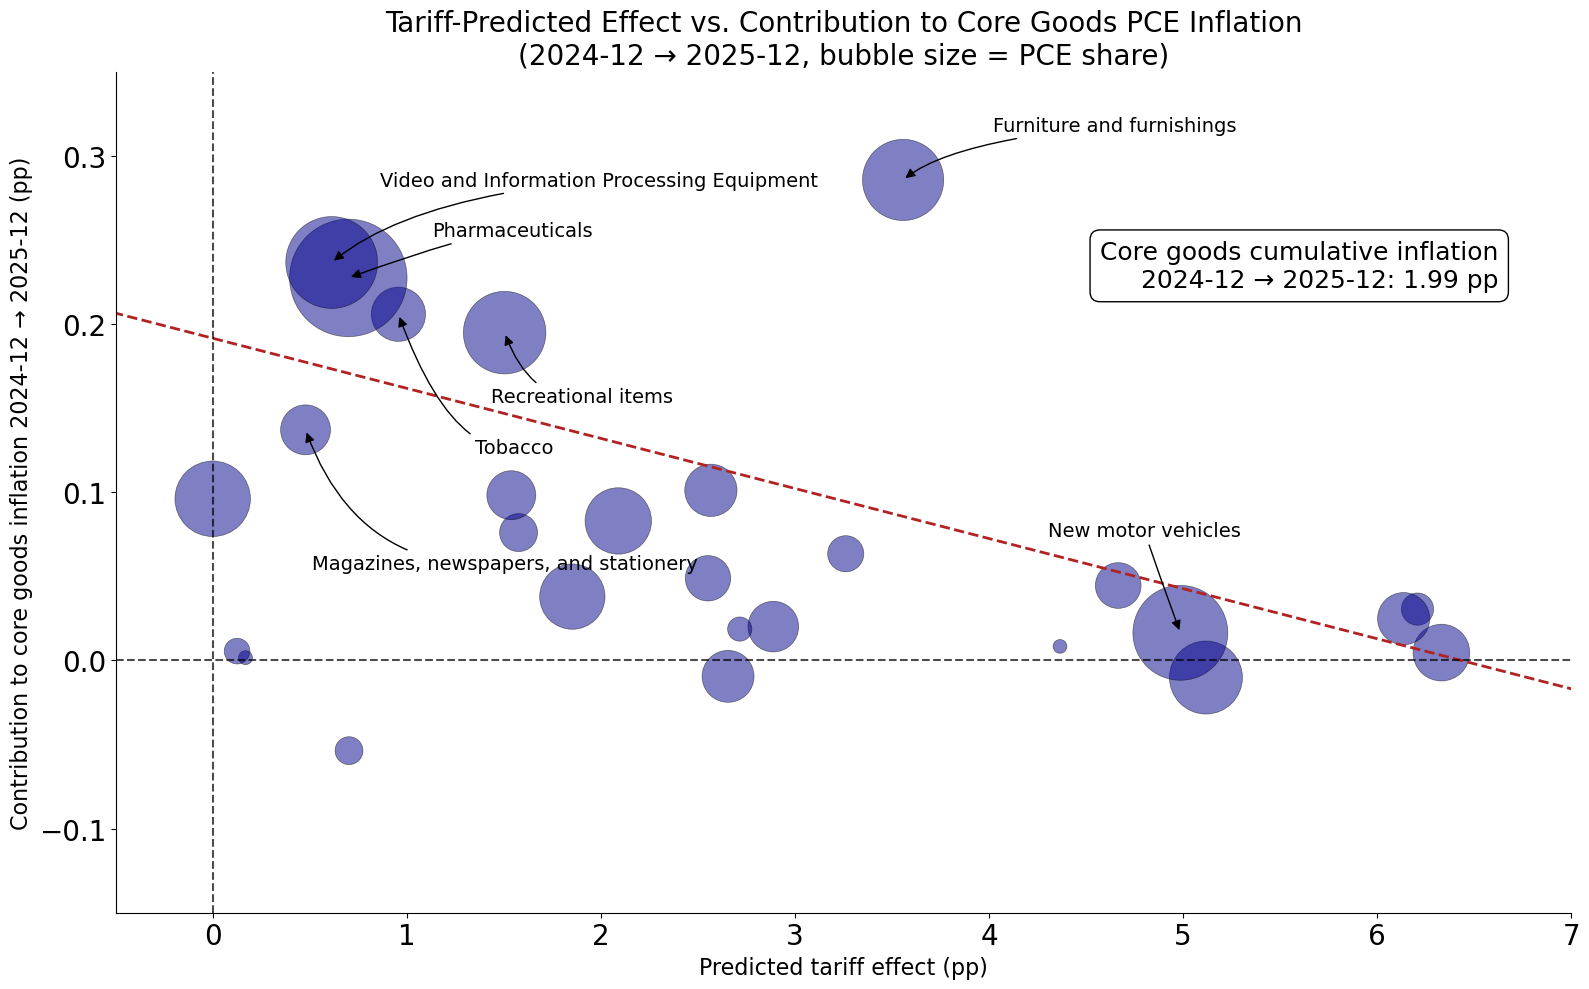

In [17]:

# ── Predicted tariff effect vs. cumulative contribution to core goods PCE ──────

# Merge predicted_effect onto the decomp frame
_dplot = _decomp.merge(
    summary_df[["PCE_category", "predicted_effect"]],
    on="PCE_category", how="left"
).dropna(subset=["predicted_effect", "contrib_cumul_pp", "pce_share"])

fig, ax = plt.subplots(figsize=(16, 10))
ax.scatter(
    _dplot["predicted_effect"] * 100,
    _dplot["contrib_cumul_pp"],
    s=_dplot["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

_x = _dplot["predicted_effect"].values * 100
_y = _dplot["contrib_cumul_pp"].values
_w = _dplot["pce_share"].values
_wls = sm.WLS(_y, sm.add_constant(_x), weights=_w).fit()
_int, _sl = _wls.params
_xf = np.linspace(_x.min() - 1.5, _x.max() + 1.5, 100)
ax.plot(_xf, _sl * _xf + _int, color="firebrick", linewidth=2, linestyle="--")

ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.set_xlim(-0.5, 7.0)
ax.set_title(
    f"Tariff-Predicted Effect vs. Contribution to Core Goods PCE Inflation\n"
    f"({_decomp_base} \u2192 {_decomp_curr}, bubble size = PCE share)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff effect (pp)", fontsize=16)
ax.set_ylabel(f"Contribution to core goods inflation {_decomp_base} \u2192 {_decomp_curr} (pp)", fontsize=16)
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_ylim(-0.15, 0.35)

# ── Summary box: cumulative inflation over the window ─────────────────────────
ax.text(
    0.95, 0.80,
    f"Core goods cumulative inflation\n{_decomp_base} \u2192 {_decomp_curr}: {_total_cumul:.2f} pp",
    transform=ax.transAxes,
    fontsize=18,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", linewidth=1),
)

# ── Annotate top 5 categories by PCE share ────────────────────────────────────
_top5 = _dplot.nlargest(5, "pce_share").reset_index(drop=True)
annotate_fontsize = 14

ax.annotate(  # pharmaceuticals
    "Pharmaceuticals",
    xy=(_top5.loc[0, "predicted_effect"] * 100, _top5.loc[0, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(60, 30),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=20", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # new motor vehicles
    _top5.loc[1, "PCE_category"],
    xy=(_top5.loc[1, "predicted_effect"] * 100, _top5.loc[1, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(-95, 70),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # video & info processing equipment
    "Video and Information Processing Equipment",
    xy=(_top5.loc[2, "predicted_effect"] * 100, _top5.loc[2, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(35, 55),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # recreational items
    _top5.loc[3, "PCE_category"],
    xy=(_top5.loc[3, "predicted_effect"] * 100, _top5.loc[3, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(-10, -50),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # furniture & furnishings
    _top5.loc[4, "PCE_category"],
    xy=(_top5.loc[4, "predicted_effect"] * 100, _top5.loc[4, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(65, 35),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

# ── Annotate top 2 contributors to goods inflation (by contrib_cumul_pp) ──────
# Skip any already labeled in the top-5-by-PCE-share block above
_already_labeled = set(_top5["PCE_category"].tolist()) | {"Pharmaceuticals",
                                                           "Video and Information Processing Equipment"}
_top2_contrib = (
    _dplot[~_dplot["PCE_category"].isin(_already_labeled)]
    .nlargest(2, "contrib_cumul_pp")
    .reset_index(drop=True)
)

ax.annotate(  # top contributor (rank 1)
    _top2_contrib.loc[0, "PCE_category"],
    xy=(_top2_contrib.loc[0, "predicted_effect"] * 100, _top2_contrib.loc[0, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(55, -100),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # top contributor (rank 2)
    _top2_contrib.loc[1, "PCE_category"],
    xy=(_top2_contrib.loc[1, "predicted_effect"] * 100, _top2_contrib.loc[1, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(5, -100),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

plt.tight_layout()
plt.savefig("tariff_vs_contribution.png", bbox_inches="tight", dpi=150)
plt.show()


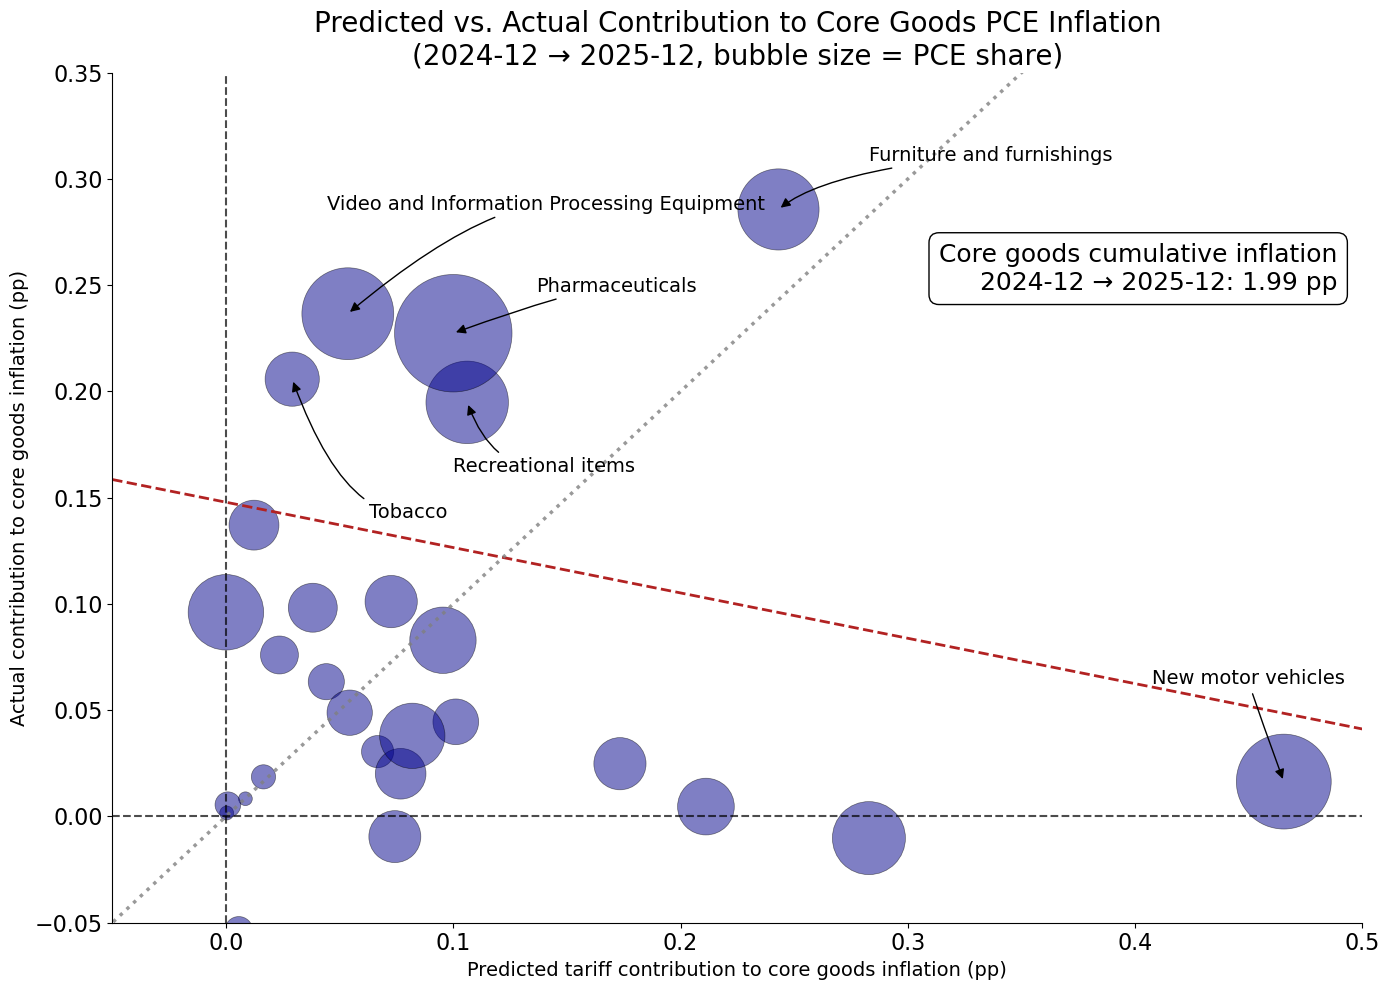

In [18]:

# ── Predicted contribution vs. actual contribution — same-units scatter ────────
# X: predicted tariff contribution to core goods PCE (weight × predicted_effect, pp)
# Y: actual cumulative contribution to core goods PCE (weight × inflation_cumul, pp)
# Both axes in percentage-point contributions, so the 45° line = perfect prediction.

_dplot2 = _dplot.copy()
_dplot2["predicted_contrib_pp"] = _dplot2["weight"] * _dplot2["predicted_effect"] * 100

_d2 = _dplot2.dropna(subset=["predicted_contrib_pp", "contrib_cumul_pp", "pce_share"])

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(
    _d2["predicted_contrib_pp"],
    _d2["contrib_cumul_pp"],
    s=_d2["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

_x2 = _d2["predicted_contrib_pp"].values
_y2 = _d2["contrib_cumul_pp"].values
_w2 = _d2["pce_share"].values
_wls2 = sm.WLS(_y2, sm.add_constant(_x2), weights=_w2).fit()
_int2, _sl2 = _wls2.params
_xf2 = np.linspace(_x2.min() - 0.05, _x2.max() + 0.05, 100)
ax.plot(_xf2, _sl2 * _xf2 + _int2, color="firebrick", linewidth=2, linestyle="--",
        label=f"WLS fit (slope={_sl2:.2f})")

# 45° perfect-prediction line
_xy_min = min(_x2.min(), _y2.min()) - 0.05
_xy_max = max(_x2.max(), _y2.max()) + 0.05
ax.plot([_xy_min, _xy_max], [_xy_min, _xy_max],
        color="gray", linewidth=2.5, linestyle=":", alpha=0.8, label="45° (perfect prediction)")

ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

ax.set_title(
    f"Predicted vs. Actual Contribution to Core Goods PCE Inflation\n"
    f"({_decomp_base} \u2192 {_decomp_curr}, bubble size = PCE share)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff contribution to core goods inflation (pp)", fontsize=14)
ax.set_ylabel(f"Actual contribution to core goods inflation (pp)", fontsize=14)
# ax.legend(fontsize=12, frameon=False, loc="upper left")
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)



ax.set_ylim(-0.05, 0.35)
ax.set_xlim(-0.05, 0.5)

# ── Summary box ───────────────────────────────────────────────────────────────
ax.text(
    0.98, 0.80,
    f"Core goods cumulative inflation\n{_decomp_base} \u2192 {_decomp_curr}: {_total_cumul:.2f} pp",
    transform=ax.transAxes,
    fontsize=18,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", linewidth=1),
)

# ── Annotate top 5 categories by PCE share ────────────────────────────────────
_top5_2 = _d2.nlargest(5, "pce_share").reset_index(drop=True)
annotate_fontsize = 14

ax.annotate(  # pharmaceuticals
    "Pharmaceuticals",
    xy=(_top5_2.loc[0, "predicted_contrib_pp"], _top5_2.loc[0, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(60, 30),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=20", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # new motor vehicles
    _top5_2.loc[1, "PCE_category"],
    xy=(_top5_2.loc[1, "predicted_contrib_pp"], _top5_2.loc[1, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(-95, 70),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # video & info processing equipment
    "Video and Information Processing Equipment",
    xy=(_top5_2.loc[2, "predicted_contrib_pp"], _top5_2.loc[2, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(-15, 75),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # recreational items
    _top5_2.loc[3, "PCE_category"],
    xy=(_top5_2.loc[3, "predicted_contrib_pp"], _top5_2.loc[3, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(-10, -50),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # furniture & furnishings
    _top5_2.loc[4, "PCE_category"],
    xy=(_top5_2.loc[4, "predicted_contrib_pp"], _top5_2.loc[4, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(65, 35),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

# ── Annotate top 2 contributors (by actual contrib_cumul_pp, not already labeled) ───
_already_labeled2 = set(_top5_2["PCE_category"].tolist()) | {"Pharmaceuticals",
                                                              "Video and Information Processing Equipment"}
_top2_contrib2 = (
    _d2[~_d2["PCE_category"].isin(_already_labeled2)]
    .nlargest(2, "contrib_cumul_pp")
    .reset_index(drop=True)
)

ax.annotate(  # top contributor (rank 1)
    _top2_contrib2.loc[0, "PCE_category"],
    xy=(_top2_contrib2.loc[0, "predicted_contrib_pp"], _top2_contrib2.loc[0, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(55, -100),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

# ax.annotate(  # top contributor (rank 2)
#     _top2_contrib2.loc[1, "PCE_category"],
#     xy=(_top2_contrib2.loc[1, "predicted_contrib_pp"], _top2_contrib2.loc[1, "contrib_cumul_pp"]),
#     xycoords="data",
#     xytext=(5, -100),
#     textcoords="offset points",
#     horizontalalignment="left",
#     arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
#     fontsize=annotate_fontsize,
# )

plt.tight_layout()
plt.savefig("tariff_vs_contribution_same_units.png", bbox_inches="tight", dpi=150)
plt.show()


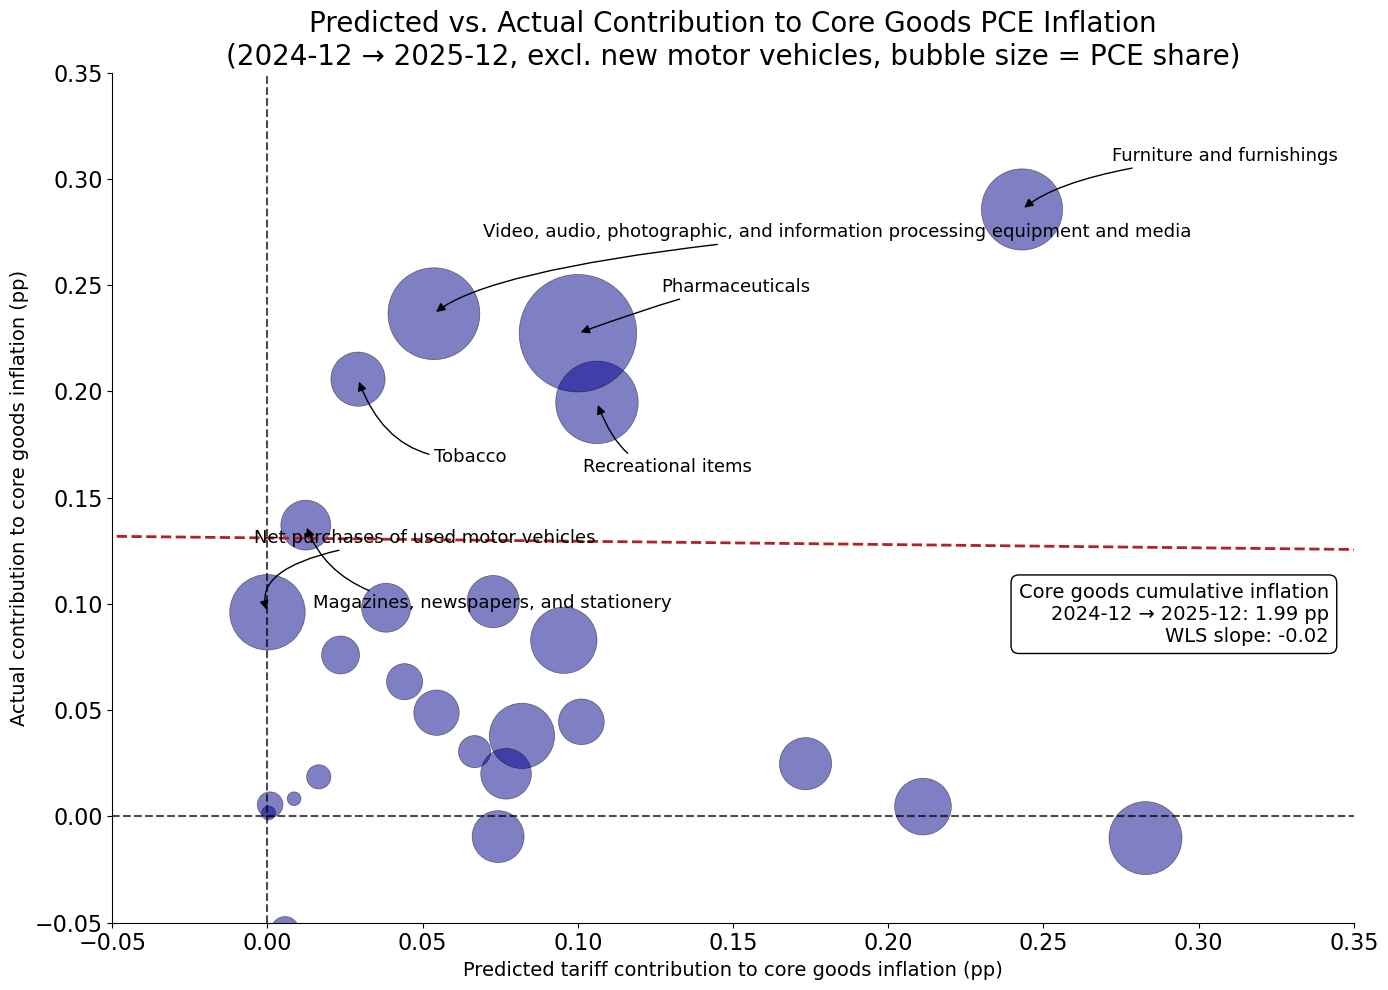

In [19]:

# ── Predicted vs. actual contribution — same-units scatter, excl. new motor vehicles ──

_new_mv_category = _dplot2.loc[_dplot2["pce_share"].idxmax(), "PCE_category"]  # sanity check label
_d3 = _dplot2[_dplot2["PCE_category"] != "New motor vehicles"].dropna(
    subset=["predicted_contrib_pp", "contrib_cumul_pp", "pce_share"]
)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(
    _d3["predicted_contrib_pp"],
    _d3["contrib_cumul_pp"],
    s=_d3["pce_share"] * 50000,
    alpha=0.5, color="darkblue", edgecolors="black", linewidths=0.5,
)

_x3 = _d3["predicted_contrib_pp"].values
_y3 = _d3["contrib_cumul_pp"].values
_w3 = _d3["pce_share"].values
_wls3 = sm.WLS(_y3, sm.add_constant(_x3), weights=_w3).fit()
_int3, _sl3 = _wls3.params
_xf3 = np.linspace(_x3.min() - 0.10, _x3.max() + 0.10, 100)
ax.plot(_xf3, _sl3 * _xf3 + _int3, color="firebrick", linewidth=2, linestyle="--")

ax.axhline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)

ax.set_title(
    f"Predicted vs. Actual Contribution to Core Goods PCE Inflation\n"
    f"({_decomp_base} \u2192 {_decomp_curr}, excl. new motor vehicles, bubble size = PCE share)",
    fontsize=20,
)
ax.set_xlabel("Predicted tariff contribution to core goods inflation (pp)", fontsize=14)
ax.set_ylabel("Actual contribution to core goods inflation (pp)", fontsize=14)
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.set_ylim(-0.05, 0.35)
ax.set_xlim(-0.05, 0.35)

# ── Summary box: cumulative inflation + regression slope ──────────────────────
ax.text(
    0.98, 0.40,
    f"Core goods cumulative inflation\n"
    f"{_decomp_base} \u2192 {_decomp_curr}: {_total_cumul:.2f} pp\n"
    f"WLS slope: {_sl3:.2f}",
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", linewidth=1),
)

# ── Annotate top 5 categories by PCE share (excl. new motor vehicles) ─────────
_top5_3 = _d3.nlargest(5, "pce_share").reset_index(drop=True)
annotate_fontsize = 13

ax.annotate(  # pharmaceuticals
    "Pharmaceuticals",
    xy=(_top5_3.loc[0, "predicted_contrib_pp"], _top5_3.loc[0, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(60, 30),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=20", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # rank 2 by pce share (was rank 3 before removing motor vehicles)
    _top5_3.loc[1, "PCE_category"],
    xy=(_top5_3.loc[1, "predicted_contrib_pp"], _top5_3.loc[1, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(35, 55),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # rank 3
    _top5_3.loc[2, "PCE_category"],
    xy=(_top5_3.loc[2, "predicted_contrib_pp"], _top5_3.loc[2, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(-10, -50),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # rank 4
    _top5_3.loc[3, "PCE_category"],
    xy=(_top5_3.loc[3, "predicted_contrib_pp"], _top5_3.loc[3, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(65, 35),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=40", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(  # rank 5
    _top5_3.loc[4, "PCE_category"],
    xy=(_top5_3.loc[4, "predicted_contrib_pp"], _top5_3.loc[4, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(-10, 50),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

# ── Annotate top 2 contributors (by actual contrib, not already labeled) ──────
_already_labeled3 = set(_top5_3["PCE_category"].tolist()) | {"Pharmaceuticals"}
_top2_contrib3 = (
    _d3[~_d3["PCE_category"].isin(_already_labeled3)]
    .nlargest(2, "contrib_cumul_pp")
    .reset_index(drop=True)
)

ax.annotate(
    _top2_contrib3.loc[0, "PCE_category"],
    xy=(_top2_contrib3.loc[0, "predicted_contrib_pp"], _top2_contrib3.loc[0, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(55, -60),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

ax.annotate(
    _top2_contrib3.loc[1, "PCE_category"],
    xy=(_top2_contrib3.loc[1, "predicted_contrib_pp"], _top2_contrib3.loc[1, "contrib_cumul_pp"]),
    xycoords="data",
    xytext=(5, -60),
    textcoords="offset points",
    horizontalalignment="left",
    arrowprops={"arrowstyle": "-|>", "connectionstyle": "angle3,angleA=5,angleB=110", "color": "black"},
    fontsize=annotate_fontsize,
)

plt.tight_layout()
plt.savefig("tariff_vs_contribution_ex_mv.png", bbox_inches="tight", dpi=150)
plt.show()


In [20]:
_out["Contrib. cumul (pp)"].iloc[0:6].sum()  # should equal the total cumulative inflation computed above

np.float64(1.2874541023058916)

In [21]:
_annualized_m.sort_values(ascending=False).head(35)

LineDescription
Tobacco (127)                                                                                          0.07
Educational books (96)                                                                                 0.05
Musical instruments (part of 80)                                                                       0.05
Jewelry and watches (part of 119)                                                                      0.03
Magazines, newspapers, and stationery (part of 90)                                                     0.03
Therapeutic appliances and equipment (42)                                                              0.02
Tools and equipment for house and garden (35)                                                          0.02
Motor vehicle parts and accessories (58)                                                               0.02
Children's and infants' clothing (12)                                                                  0.02
Pharmaceutic